<center>
    <h1 style="color:green">
        <b>
            <u> PROJECT MACHINE LEARNING </u>
        </b>
    </h1>
</center>

# Introduction

Ce projet est réalisé dans le cadre du Master 2 Data Science à Aix-Marseille Université sous la supervision de Massinissa Saïdi, Data Scientist. L'objectif principal est de développer un modèle de prédiction des prix des maisons en utilisant différentes techniques de machine learning, tout en acquérant des compétences pratiques en data science. Ce projet permet de se familiariser avec les bibliothèques courantes telles que NumPy, pandas, scikit-learn, et d'approfondir la compréhension des concepts tels que la préparation des données, la régression, et l'évaluation des performances des modèles.

La problématique consiste à déterminer comment différentes caractéristiques d'une maison (comme la superficie, le nombre de chambres, la localisation, etc.) influencent son prix. Nous appliquerons une méthodologie rigoureuse, comprenant l'exploration des données, la construction de différents modèles de régression, et l'évaluation de leurs performances afin de sélectionner le meilleur modèle.


# Bibliothèques et libraries

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
import missingno as msno
import seaborn as sns

from statsmodels.formula.api import ols
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.impute import KNNImputer
from sklearn.exceptions import FitFailedWarning
from sklearn.metrics import mean_absolute_error, mean_squared_error

from scipy.stats import f_oneway


# Importation fonctions
from src.data_processing.load_data import load_data
from config.config import TEST_RATIO, SEED
from src.data_science.data import split_data, encoder_var, transformer_binaire_en_entier, acm, plot_acm_modalities

# 1. Analyse Exploratoire des Données (EDA)

## 1.1 Importation des données

L'importation des données se fait via la fonction load_data.

In [242]:
# imporation des données 

house_prices = load_data('data/raw/house_prices.csv')

# visualiser les premières lignes du jeu de données
house_prices.head()

Data loaded successfully from data/raw/house_prices.csv


,price,AreA,bedrooms,BATHROOMS,stories,mainroad,guestroom,basement,hotwaterheating,air conditioning,parking,prefarea,furnishing STATUS,houSeaGe
0,4543000.0,4990.0,4.0,2.0,2.0,yes,yes,yes,no,no,0.0,yes,furnished,15.0
1,8080940.0,7000.0,3.0,2.0,4.0,yes,no,no,no,yes,2.0,no,FURNISHED,11.0
2,8750000.0,4321.0,3.0,2.0,2.0,yes,no,yes,yes,no,2.0,no,FURNISHED,NaN
3,1890000.0,1700.0,3.0,1.0,2.0,yes,no,no,no,no,0.0,no,unfurnished,NaN
4,12215000.0,7500.0,4.0,2.0,2.0,yes,no,yes,no,yes,3.0,yes,furnished,NaN


In [199]:
#Types de variables
print(house_prices.dtypes)
print("Taille du jeu de données: ", house_prices.shape)

price                float64
AreA                 float64
bedrooms             float64
BATHROOMS            float64
stories              float64
mainroad              object
guestroom             object
basement              object
hotwaterheating       object
air conditioning      object
parking              float64
prefarea              object
furnishing STATUS     object
houSeaGe             float64
dtype: object
Taille du jeu de données:  (809, 14)


Nous avons un jeu de données de 809 observations et 14 variables dont sept variables numériques et sept non numériques.

In [200]:
# Statistique descriptive des colonnes
house_prices.describe(include = "all")
#print(house_prices.info)

,price,AreA,bedrooms,BATHROOMS,stories,mainroad,guestroom,basement,hotwaterheating,air conditioning,parking,prefarea,furnishing STATUS,houSeaGe
count,7.890000e+02,794.000000,785.000000,788.000000,794.000000,793,786,787,791,794,793.000000,795,786,5.00000
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,5,NaN
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,semi-furnished,NaN
freq,NaN,NaN,NaN,NaN,NaN,703,621,507,741,481,NaN,591,316,NaN
mean,5.406437e+06,5482.997481,3.048408,1.469543,1.935768,NaN,NaN,NaN,NaN,NaN,0.825977,NaN,NaN,35.00000
std,2.217827e+06,2203.340686,0.742445,0.669037,0.951354,NaN,NaN,NaN,NaN,NaN,0.874718,NaN,NaN,27.10166
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,11.00000
25%,3.640000e+06,3665.000000,3.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,15.00000
50%,4.893000e+06,5310.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,28.00000
75%,7.210000e+06,6601.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,43.00000


## 1.2 Nettoyage des données 

### 1.2.1 Formatage des données

In [201]:
## Renommer les colonnes 

# noms des colonnes
nom_col = ["prix", "superficie", "chambres", "salles_de_bain", "etages",
"route_principale", "chambre_amis", "sous_sol", "eau_chaude", "climatisation",
"parking", "zone_preferee", "ameublement", "age_maison"]

house_prices.columns = nom_col 

# afficher la table  pour tester
print(house_prices.head(10))

         prix  superficie  chambres  salles_de_bain  etages route_principale  \
0   4543000.0      4990.0       4.0             2.0     2.0              yes   
1   8080940.0      7000.0       3.0             2.0     4.0              yes   
2   8750000.0      4321.0       3.0             2.0     2.0              yes   
3   1890000.0      1700.0       3.0             1.0     2.0              yes   
4  12215000.0      7500.0       4.0             2.0     2.0              yes   
5   2275000.0      3970.0       3.0             1.0     2.0              yes   
6   8400000.0      5500.0       4.0             2.0     2.0              yes   
7         NaN      3520.0       3.0             1.0     1.0              yes   
8   6230000.0      6600.0       3.0             2.0     1.0              yes   
9   2730000.0      4000.0       3.0             1.0     2.0              yes   

  chambre_amis sous_sol eau_chaude climatisation  parking zone_preferee  \
0          yes      yes         no          

Ici on voit que la variable ameublement est censé avoir 3 modalités, Il semble que dans l'écriture des modalités y a des erreurs entre les majuscules et les minuscules. Nous allons corriger ça en recodant cette variable. 

In [202]:

# recodage pour corriger les modalités

house_prices['ameublement'] = house_prices['ameublement'].replace({
    'FURNISHED': 'Furnished',
    'furnished': 'Furnished',
    'semi-furnished': 'SemiFurnished',
    'unfurnished': 'Unfurnished',
})

# Vérifions si l'encodage est pris en compte
house_prices['ameublement'].unique()

array(['Furnished', 'Unfurnished', 'SemiFurnished', nan], dtype=object)

In [203]:
## Statistiques descriptives
house_prices.describe()

,prix,superficie,chambres,salles_de_bain,etages,parking,age_maison
count,7.890000e+02,794.000000,785.000000,788.000000,794.000000,793.000000,5.00000
mean,5.406437e+06,5482.997481,3.048408,1.469543,1.935768,0.825977,35.00000
std,2.217827e+06,2203.340686,0.742445,0.669037,0.951354,0.874718,27.10166
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,11.00000
25%,3.640000e+06,3665.000000,3.000000,1.000000,1.000000,0.000000,15.00000
50%,4.893000e+06,5310.000000,3.000000,1.000000,2.000000,1.000000,28.00000
75%,7.210000e+06,6601.000000,3.000000,2.000000,2.000000,2.000000,43.00000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000,78.00000


### 1.2.2 Valeurs manquantes

In [204]:
#print(house_prices[house_prices.isnull().any(axis=1)])

In [205]:
# Pourcentage de données manquantes par variable 
(house_prices.isna().sum()/809)*100

prix                 2.472188
superficie           1.854141
chambres             2.966625
salles_de_bain       2.595797
etages               1.854141
route_principale     1.977750
chambre_amis         2.843016
sous_sol             2.719407
eau_chaude           2.224969
climatisation        1.854141
parking              1.977750
zone_preferee        1.730532
ameublement          2.843016
age_maison          99.381953
dtype: float64

In [206]:
#print("Valeurs uniques pour 'route_principale':", house_prices['route_principale'].unique())
#print("Valeurs uniques pour 'salles_de_bain':", house_prices['salles_de_bain'].unique())

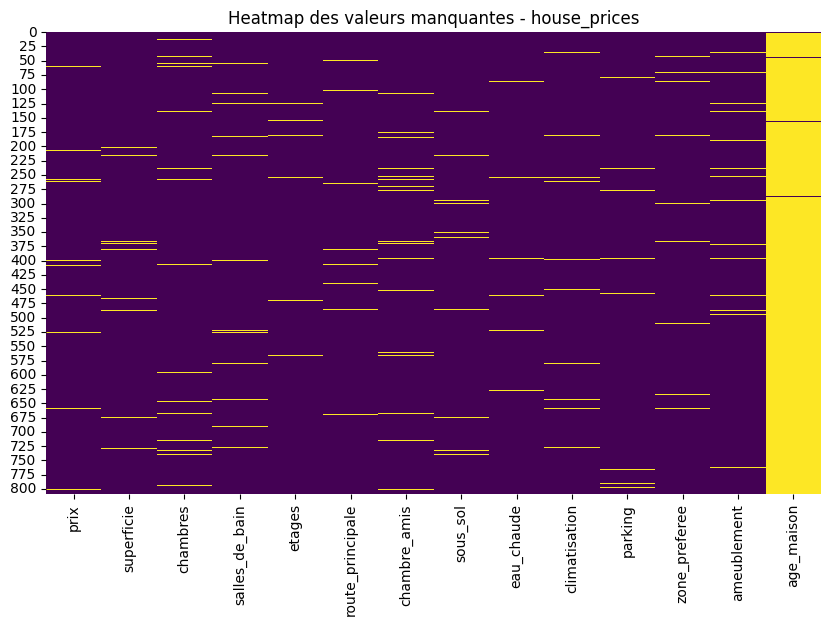

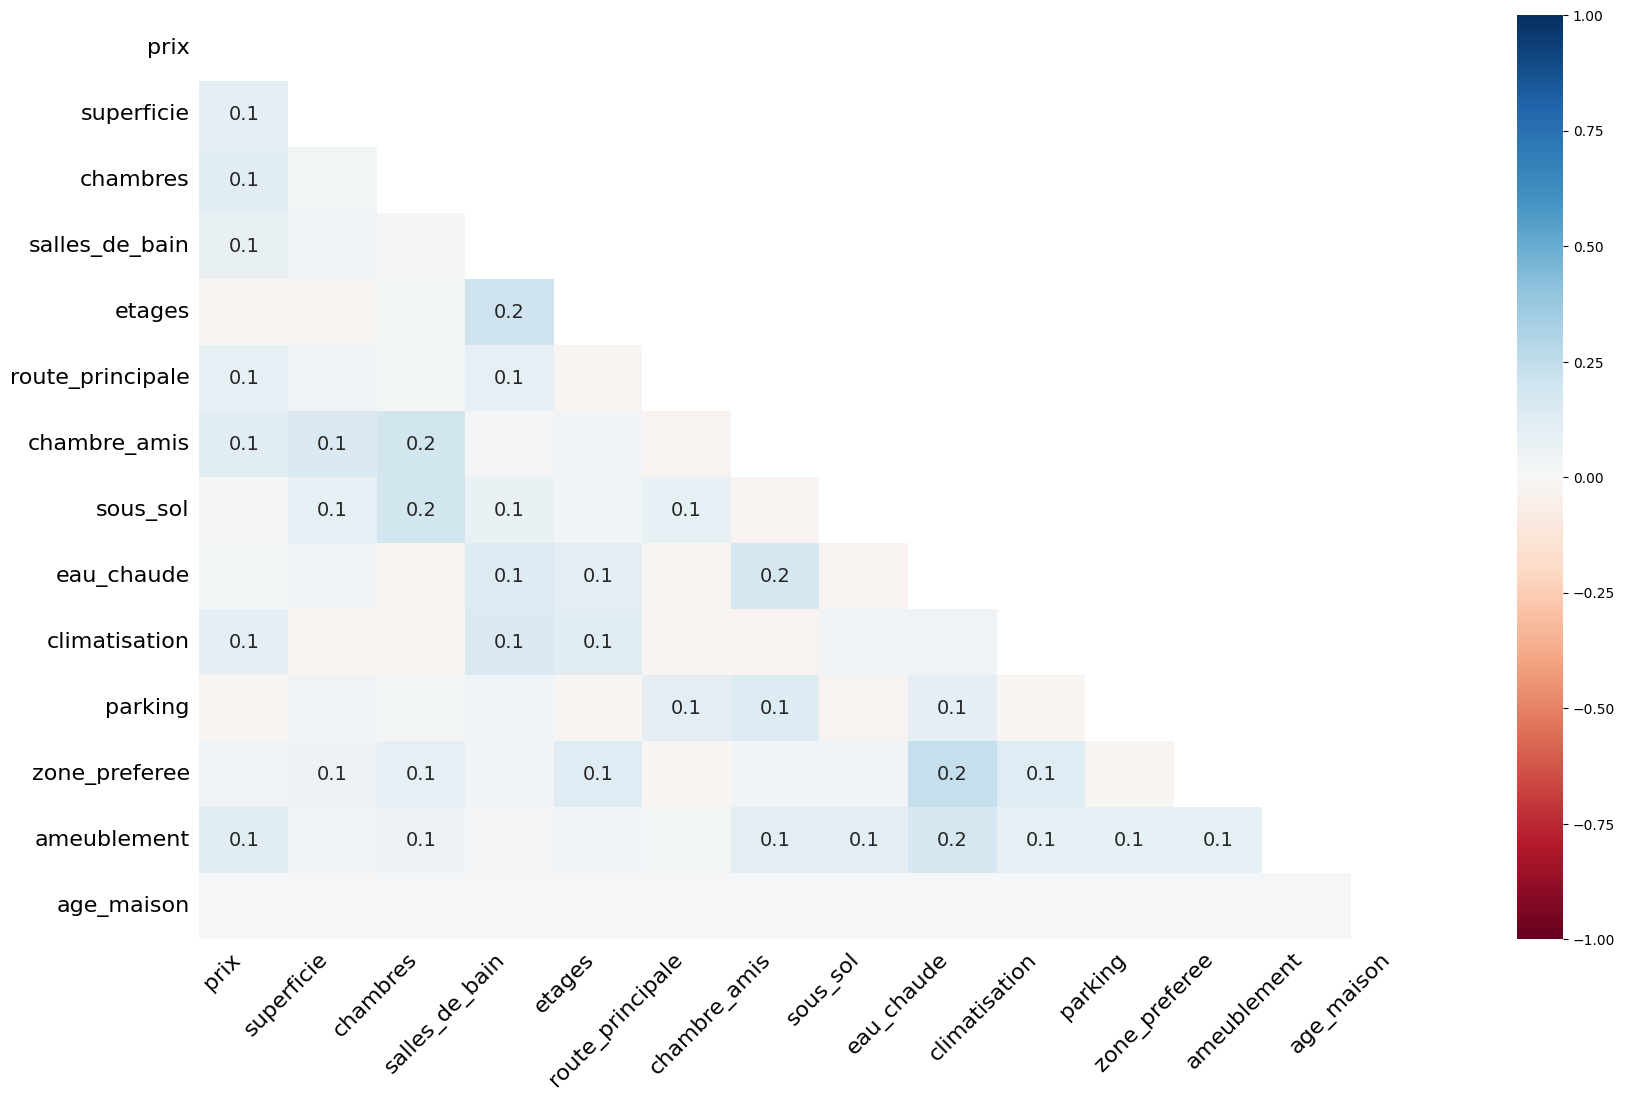

In [ ]:
# visualisation 
# Visualiser la matrice des valeurs manquantes avec seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(house_prices.isnull(), cbar=False, cmap='viridis')
plt.title(f"Heatmap des valeurs manquantes - house_prices")
plt.show()
msno.heatmap(house_prices)
plt.show() 

**- Analyse des données manquantes**:

La matrice de corrélation entre les données manquantes et les autres variables montre des corrélations très faibles (0,1 et 0,2). Cela indique que la relation entre les données manquantes et les autres covariables est faible, ce qui limite la pertinence de méthodes d'imputation complexes basées sur ces relations.

De plus, le pourcentage de données manquantes est globalement faible (entre 1,7 % et 3 %) pour la plupart des variables, à l'exception notable de la variable âge de la maison, qui contient 99 % de données manquantes et n'est donc pas exploitable dans son état actuel.

L’analyse visuelle à l’aide d’une heatmap des données manquantes suggère que les données semblent manquer de façon complètement aléatoire (MCAR). Cela justifie l’utilisation de méthodes simples d’imputation.

Par conséquent :

- Nous allons supprimer la varable age_maison 99% de ses valeurs sont manquantes.
- Pour les variables numériques, nous utiliserons une imputation par la moyenne ou la médiane.
- Pour les variables catégorielles, l’imputation se fera par la mode.

### Imputation des valeurs manquantes.

In [208]:
# Première imputation Suppression de la colonne age_maison
df = house_prices.drop(["age_maison"], axis=1) 


In [209]:
#df.columns


Maintenant nous nous allons séparer notre table en données numériques et catégorielles que nous allons définir ci dessous pour faire l'imputation. Ces deux variables seront utilisées pour la suite 

In [210]:
# Liste des variables
variables_numeriques = ["prix", "superficie", "chambres", "salles_de_bain", "etages", "parking" ]

# Liste des variables catégorielles
variables_categorielles = ["route_principale", "chambre_amis", "sous_sol","eau_chaude", "climatisation", "zone_preferee", "ameublement"]


In [ ]:
# ---- Imputation des variables numériques ----

# 1. Imputation simple (moyenne ou médiane) pour certaines variables
df['prix'] = df['prix'].fillna(df['prix'].mean())
df['superficie'] = df['superficie'].fillna(df['superficie'].median())
df['etages'] = df['etages'].fillna(df['etages'].median())
df['parking'] = df['parking'].fillna(df['parking'].median())
df['chambres'] = df['chambres'].fillna(df['chambres'].median())
df['salles_de_bain'] = df['salles_de_bain'].fillna(df['salles_de_bain'].median())


# ---- 2. Imputation des variables catégorielles ----

# Imputation par mode pour les variables catégorielles
for col in variables_categorielles:
    if df[col].isna().sum() > 0:
        mode = df[col].mode()[0]
        df[col] = df[col].fillna(mode)



La phase d'imputation est terminée maintenant pour toute la suite du projet nous allons considérer le data frame sans données manquante qu'on appelera "house"

In [212]:
house = df # notre nouveau data frame après imputation

# statistiques descriptives de la nouvelle table après imputation
house.describe(include="all") 

,prix,superficie,chambres,salles_de_bain,etages,route_principale,chambre_amis,sous_sol,eau_chaude,climatisation,parking,zone_preferee,ameublement
count,8.090000e+02,809.000000,809.000000,809.000000,809.000000,809,809,809,809,809,809.000000,809,809
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,yes,no,no,no,no,NaN,no,SemiFurnished
freq,NaN,NaN,NaN,NaN,NaN,719,644,529,759,496,NaN,605,339
mean,5.406437e+06,5479.789864,3.046972,1.457355,1.936959,NaN,NaN,NaN,NaN,NaN,0.829419,NaN,NaN
std,2.190206e+06,2182.917979,0.731382,0.664498,0.942522,NaN,NaN,NaN,NaN,NaN,0.866354,NaN,NaN
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,3.640000e+06,3700.000000,3.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
50%,4.900000e+06,5310.000000,3.000000,1.000000,2.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
75%,7.140000e+06,6600.000000,3.000000,2.000000,2.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN



Une analyse comparative des statistiques descriptives de la table avant et après l'imputation montre que les méthodes d'imputation utilisées sont fiables. Pour les variables quantitatives, les moyennes et médianes restent similaires, indiquant que les valeurs manquantes ont été remplacées de manière cohérente avec la distribution initiale des données. De même, pour les variables catégorielles, les modes avant et après imputation sont identiques, confirmant que l'imputation respecte les tendances majoritaires des données.

Ces résultats suggèrent que les techniques d'imputation appliquées (moyenne, médiane, régression, KNN, ou mode) préservent l'intégrité statistique des données et permettent une analyse robuste sans introduire de biais significatif.

## 1.3 Visualisation des données 

Après l'imputation des valeurs manquantes, nous passons à l'étape de la visualisation. Cette étape est essentielle pour explorer les données sous plusieurs angles et répondre efficacement à la problématique du projet. Elle se divise en deux parties principales :

## 1.3.1 Études univariées 
L'objectif ici est d'analyser la distribution de chaque variable indépendamment. Cela permettra de :

- Visualiser la répartition des données (par exemple, histogrammes, boxplots pour les variables quantitatives, diagrammes en barres pour les variables catégorielles).
- Détecter les éventuelles asymétries, valeurs aberrantes, ou regroupements spécifiques.


## **Variables numériques**


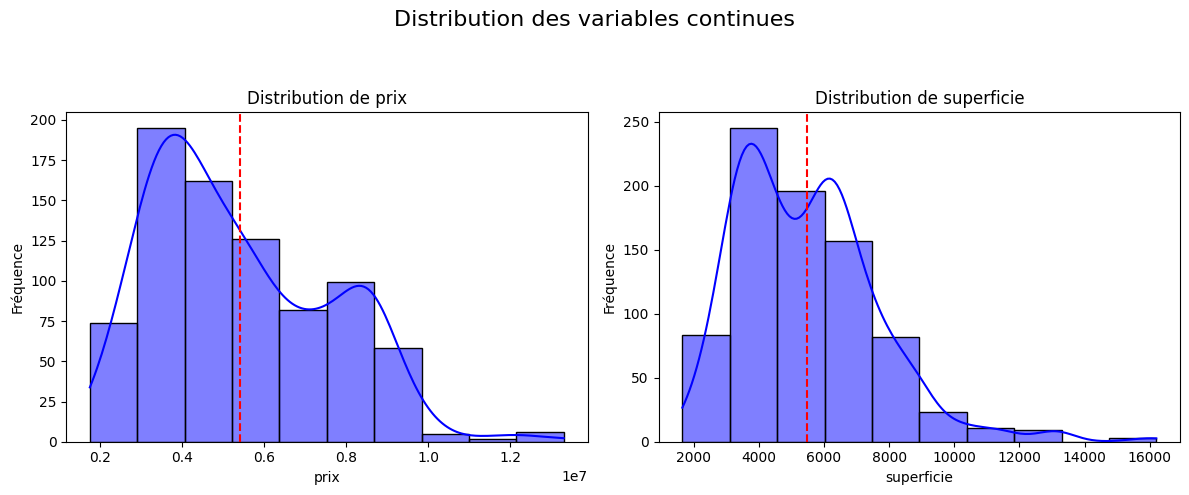

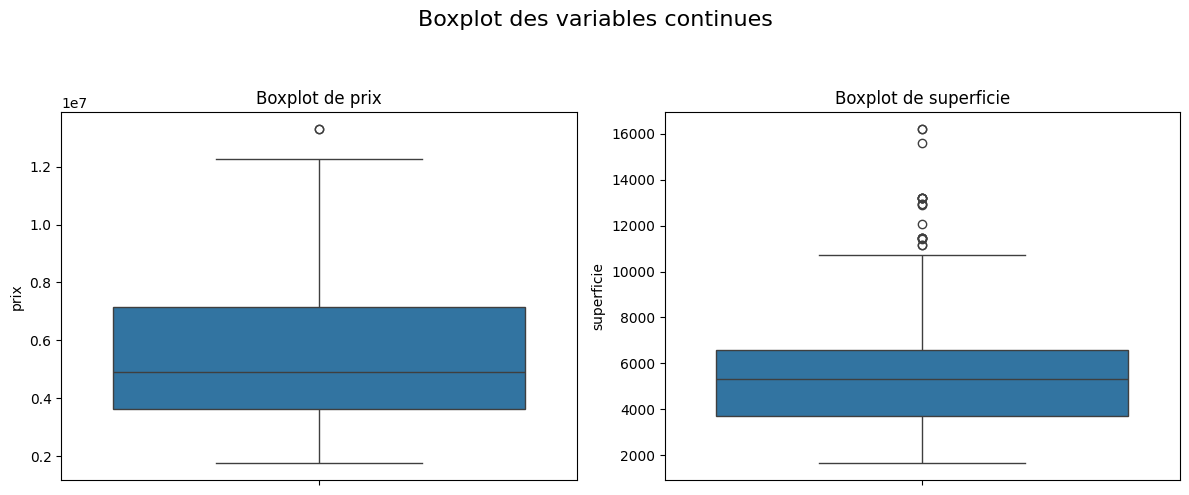

In [214]:

# Variables continues et discrètes

# On sépare en continues et discrètes
variables_continues = ["prix", "superficie"]
variables_discretes = ["chambres", "salles_de_bain", "etages", "parking"]

# Histogrammes pour variables continues 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Distribution des variables continues", fontsize=16, y=0.98)

for i, var in enumerate(variables_continues):
    sns.histplot(data=house, x=var, kde=True, bins=10, ax=axes[i], color='blue')

    # Calcul de la moyenne et de la médiane
    mean_value = house[var].mean()
    #median_value = house[var].median()
    
    # Ajouter des barres pour la moyenne et la médiane
    axes[i].axvline(mean_value, color='red', linestyle='--', label=f'Moyenne: {mean_value:.2f}')
    #axes[i].axvline(median_value, color='green', linestyle='-', label=f'Médiane: {median_value:.2f}')
    
    axes[i].set_title(f"Distribution de {var}", fontsize=12)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel("Fréquence", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Boxplot pour variables continues
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Boxplot des variables continues", fontsize=16, y=0.98)
for i, var in enumerate(variables_continues):
    sns.boxplot(data=house, y=var, ax=axes[i])
    axes[i].set_title(f"Boxplot de {var}", fontsize=12)
    axes[i].set_ylabel(var, fontsize=10)

# Ajustement de l'espacement

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()



# Analyse des variables continues : 
# prix des maisons :
L'histogramme révèle que la majorité des maisons dans notre base de données ont un prix compris entre 3 × 10⁶ et 4.05 × 10⁶ d'euros. Les autres classes de prix sont également représentées, à l'exception des maisons très chères, coûtant plus de 10 × 10⁶ d'euros, qui sont rares.

Les statistiques descriptives montrent que :

- La maison la moins chère coûte 1.75 × 10⁶ d'euros.
- La maison la plus chère est estimée à 13.33 × 10⁶ d'euros.
- La différence entre la maison la plus chère et la moins chère est significative, à environ 9.5 × 10⁶ d'euros.
- Le prix moyen des maisons est d'environ 5.50 × 10⁶ d'euros.

Le boxplot indique une distribution légèrement asymétrique, avec davantage de valeurs situées au-dessus de la médiane. - Une seule valeur aberrante est identifiée, représentant une maison beaucoup plus chère que les autres.
Les maisons les plus chères se situent dans le quartile supérieur (au-dessus de 7.5 × 10⁶ d'euros), tandis que 50 % des maisons coûtent moins de 5 × 10⁶ d'euros.

# superficie des maisons :
L'histogramme montre que la plupart des maisons ont une superficie comprise entre 3,500 m² et 4,300 m², ce qui correspond à la classe la plus représentée. Les maisons ayant une superficie supérieure à 12,000 m² sont rares et négligeables en termes de proportion.

Les statistiques descriptives montrent que :

- La maison la plus petite a une superficie de 1,650 m².
- La maison la plus grande atteint une superficie de 16,200 m².
- La superficie moyenne des maisons est de 5,480 m².

Le boxplot révèle que les données sont globalement bien réparties autour de la médiane, avec une distribution équilibrée entre les deux moitiés (50-50). Cependant, 6 valeurs aberrantes sont identifiées, représentant des maisons exceptionnellement grandes.

La médiane indique que 50 % des maisons ont une superficie inférieure à 5,500 m², tandis que les 25 % des maisons les plus grandes dépassent 11,000 m².

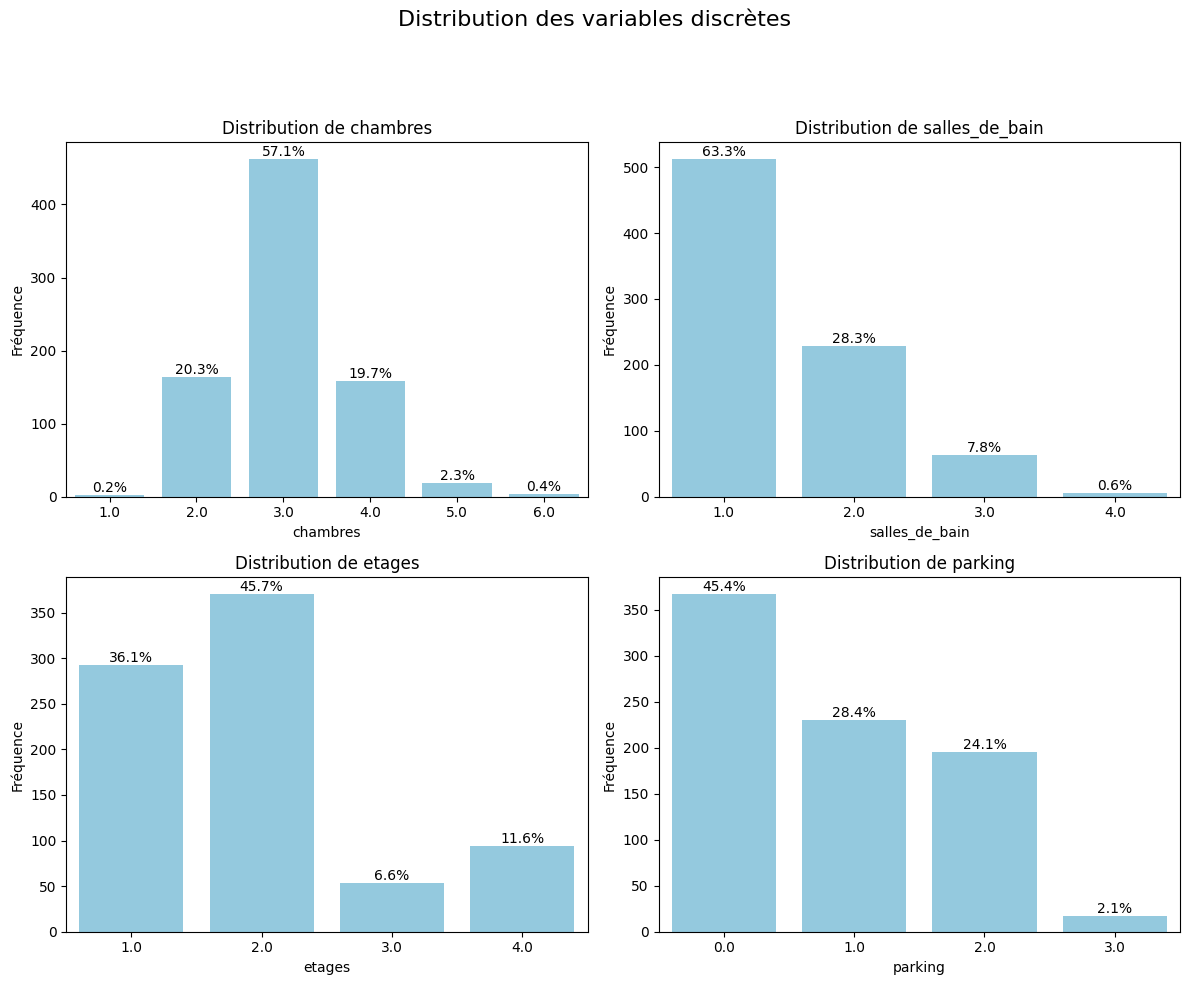

In [215]:

# Visualisation  Variables discrètes
variables_discretes = ["chambres", "salles_de_bain", "etages", "parking"]

# Figure pour variables discrètes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Distribution des variables discrètes", fontsize=16, y=0.98)

for i, var in enumerate(variables_discretes):
    ax = axes[i // 2, i % 2]
    count_data = house[var].value_counts(normalize=True) * 100  # Pourcentages
    sns.countplot(data=house, x=var, ax=ax, color='skyblue')  
    
    # Annoter chaque barre avec le pourcentage
    for p in ax.patches:
        count = p.get_height()  # Nombre d'occurrences
        percentage = count / len(house) * 100  # Calcul du pourcentage
        ax.annotate(f'{percentage:.1f}%',  # Texte à afficher
                    (p.get_x() + p.get_width() / 2, p.get_height()),  # Position du texte
                    ha='center', va='bottom', fontsize=10, color='black')
    
    ax.set_title(f"Distribution de {var}", fontsize=12)
    ax.set_xlabel(var, fontsize=10)
    ax.set_ylabel("Fréquence", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


# Analyses des variables discrètes :

Les données sur les variables discrètes montrent des tendances marquées. Concernant le nombre de chambres, il varie entre 1 et 6 par maison. La majorité des maisons disposent de 3 chambres, représentant plus de 56% de l’ensemble. Les maisons avec 2 ou 4 chambres suivent avec environ 20% chacune, tandis que celles avec 5 chambres constituent 2,3%. Les catégories restantes, comme les maisons avec 1 ou 6 chambres, sont faiblement représentées.

Pour le nombre de salles de bain, la plupart des maisons disposent d’une seule salle de bain (70%). Les maisons avec 2 salles de bain représentent environ 30%, et celles avec 3 salles de bain sont plus rares, atteignant seulement 7,8%. Les maisons avec 4 salles de bain ou plus sont marginales, presque négligeables.

En ce qui concerne les étages, 45,7% des maisons ont 2 étages, ce qui constitue la catégorie la plus fréquente. Les maisons à 1 étage sont également bien représentées avec 36%, tandis que celles avec 4 étages représentent 11,6%. Les maisons ayant plus de 4 étages sont extrêmement rares dans cet ensemble de données.

Enfin, pour le nombre de parkings, près de la moitié des maisons (45,5%) ne disposent pas de parking. Parmi celles qui en possèdent, 28,4% ont un seul parking, tandis que 24,1% en ont deux. Les maisons disposant de 3 parkings sont extrêmement rares et représentent seulement 2% des observations.

En résumé, la majorité des maisons dans cet échantillon sont relativement standards, avec un nombre modéré de chambres, de salles de bain, d’étages et de parkings. Les valeurs extrêmes ou atypiques sont peu fréquentes et pourraient correspondre à des cas spécifiques ou exceptionnels.

## **Variables catégorielles**

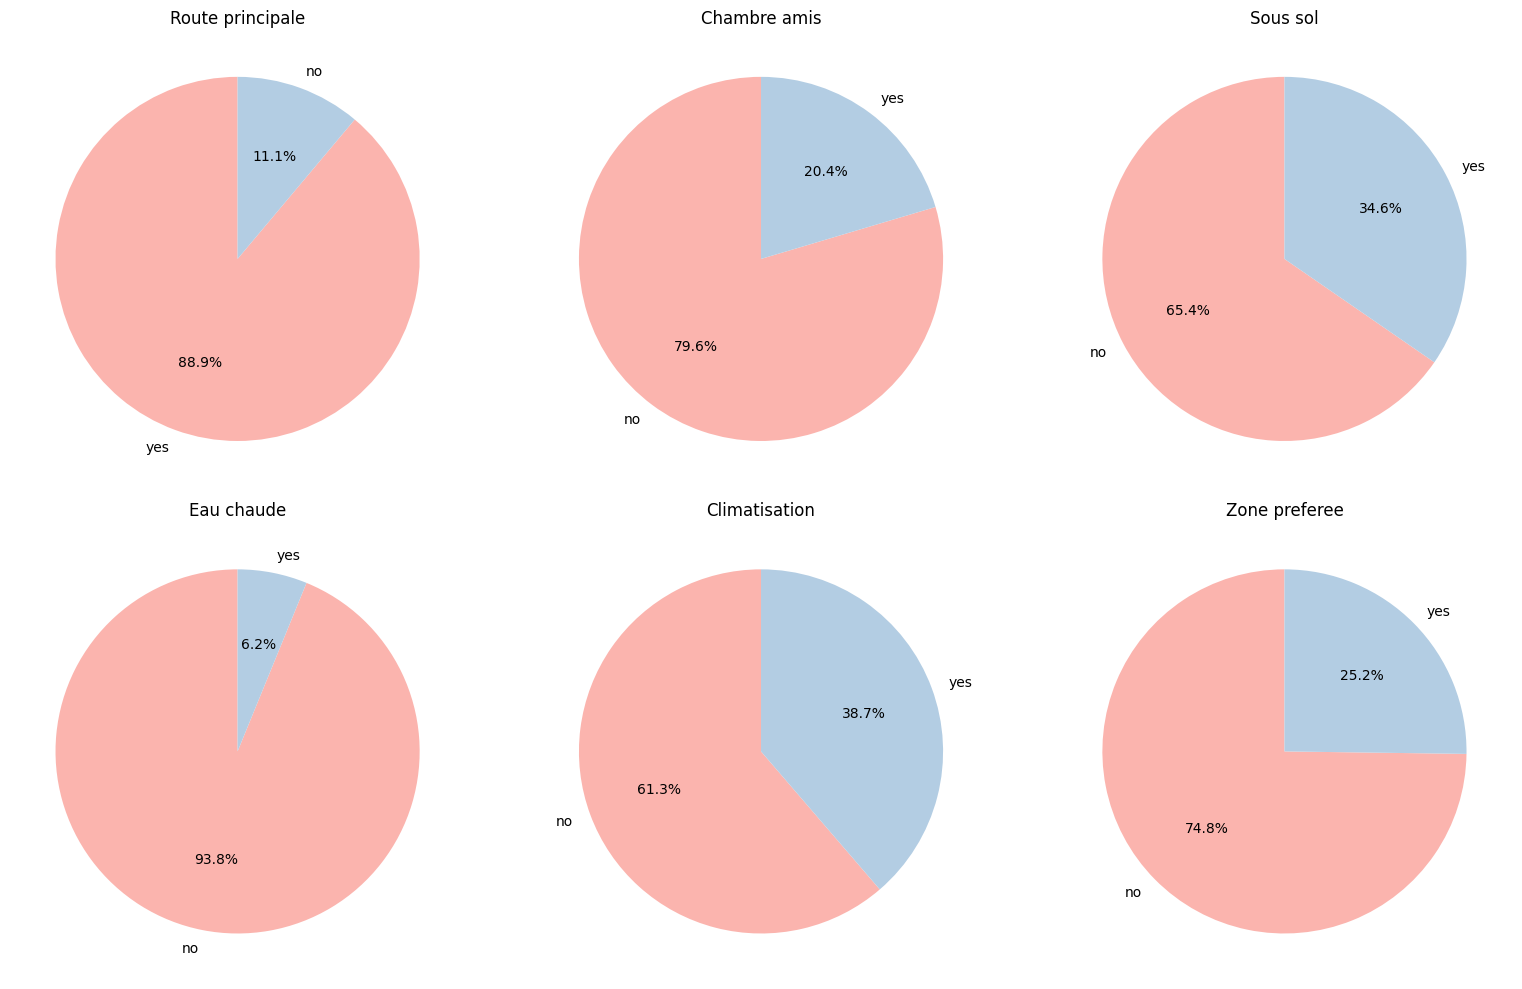

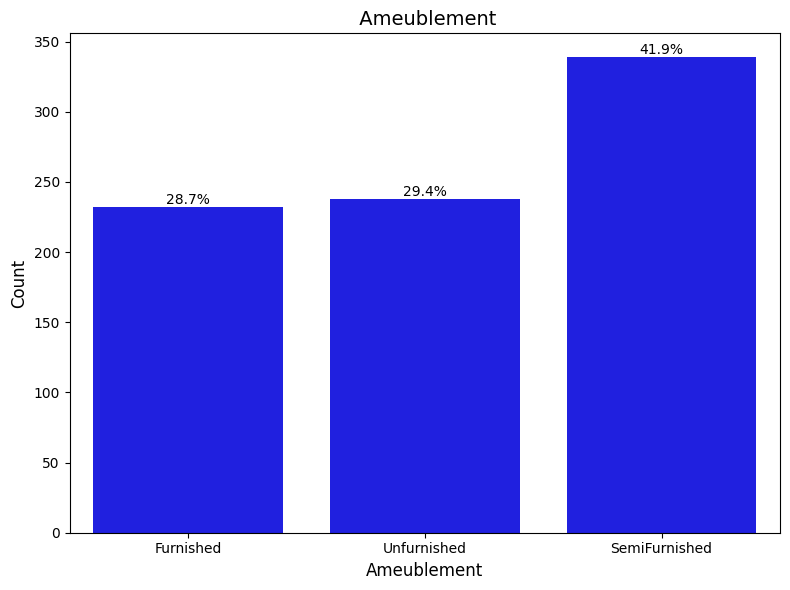

In [216]:
# 2 Visualisation des variables catégorielles

# Taille de la figure pour afficher plusieurs diagrammes circulaires
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()  # Aplatir les axes pour parcourir facilement

# Itéreration sur chaque variable catégorielle et créer un diagramme circulaire
for i, var in enumerate(variables_categorielles):
    if i < 6:  # j'ai écarté ameublement pour le faire séparément
        ax = axes[i]
        # Comptage des occurrences de chaque catégorie
        counts = house[var].value_counts()
        
        # Création du diagramme circulaire
        ax.pie(
            counts, 
            labels=counts.index, 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=plt.cm.Pastel1.colors
        )
        ax.set_title(var.replace("_", " ").capitalize(), fontsize=12)

# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()
plt.show()


## Création d'un barplot pour la variable 'ameublement' 

# Créer le graphique en barres
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=house, x='ameublement', color='blue')

# Ajouter les pourcentages sur chaque barre
total = len(house)  # Total des observations
for p in ax.patches:
    count = p.get_height()  # Hauteur de la barre
    percentage = count / total * 100  # Calcul du pourcentage
    ax.annotate(f'{percentage:.1f}%',  # Texte affiché
                (p.get_x() + p.get_width() / 2, p.get_height()),  # Position au-dessus de la barre
                ha='center', va='bottom', fontsize=10, color='black')

# Ajouter un titre et des étiquettes
plt.title(' Ameublement', fontsize=14)
plt.xlabel('Ameublement', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Afficher le graphique
plt.tight_layout()
plt.show()





Une analyse des variables catégorielles binaires révèle des tendances intéressantes sur les caractéristiques des maisons. La majorité des maisons (89%) sont situées le long de routes principales, ce qui peut indiquer une préférence pour des emplacements facilement accessibles. En revanche, 11% des maisons sont dans des zones plus reculées ou moins accessibles.

En ce qui concerne les commodités, seulement 20,4% des maisons disposent d’une chambre pour amis, ce qui pourrait refléter une caractéristique moins courante dans cet ensemble de données. De même, seules 34,6% des maisons possèdent un sous-sol, ce qui peut être influencé par des facteurs géographiques ou architecturaux.

L’accès à l’eau chaude est particulièrement faible, avec seulement 6,2% des maisons en étant équipées, ce qui peut être un indicateur d’une infrastructure plus basique ou de la région étudiée. La climatisation est présente dans 38,7% des maisons, une proportion modérée qui peut dépendre du climat de la région ou des préférences des habitants.

En ce qui concerne le statut d'ameublement des maisons, la majorité des maisons sont semi-meublées. Par ailleurs, les maisons entièrement meublées et celles non meublées sont réparties de manière relativement équilibrée, avec des proportions presque équivalentes.

Enfin, seulement 25,2% des maisons se trouvent dans des zones considérées comme préférées ou privilégiées. Cela pourrait refléter une répartition géographique ou socio-économique où la majorité des maisons sont situées dans des zones moins prisées.



Ces résultats montrent que les maisons dans cet ensemble de données sont majoritairement situées près des routes principales, mais beaucoup n’offrent pas des équipements ou caractéristiques considérés comme haut de gamme (chambres d’amis, sous-sols, climatisation, etc.). Cela suggère que les maisons étudiées appartiennent principalement à des catégories standards ou intermédiaires, avec un accès limité à certaines commodités modernes.



## 1.3.2 Études multivariées 
Dans cette étape, nous examinerons :

- Les relations entre la variable à expliquer et les caractéristiques (par exemple, scatter plots, boxplots groupés).
- Les interactions entre les caractéristiques elles-mêmes pour identifier des corrélations ou des dépendances importantes (par exemple, matrices de corrélation, heatmaps).

In [217]:
# Calcul des corrélation entre les variables nuériques
correlations = house[variables_numeriques].corr()
print(correlations['prix'])


prix              1.000000
superficie        0.529300
chambres          0.397980
salles_de_bain    0.615856
etages            0.429652
parking           0.451830
Name: prix, dtype: float64


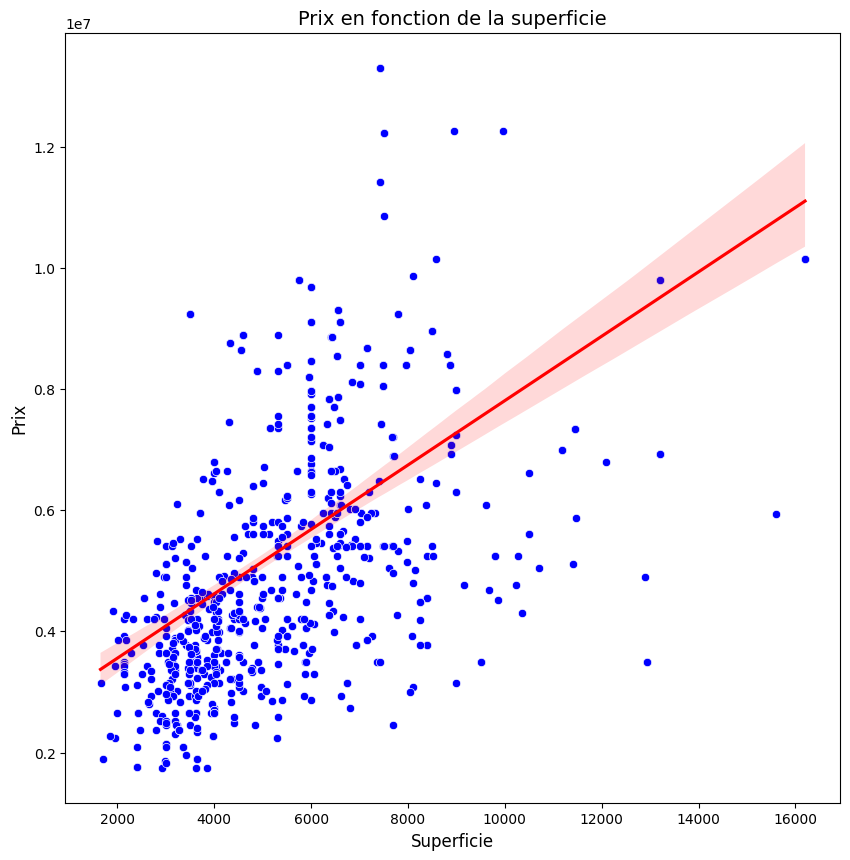

In [218]:
# scarterplot pour la variable superficie et prix
plt.figure(figsize=(10, 10))
sns.scatterplot(data=house, x='superficie', y='prix', color='blue')

# ajouter la droite de régression
sns.regplot(data=house, x='superficie', y='prix', scatter=False, color='red')

plt.title("Prix en fonction de la superficie", fontsize=14)
plt.xlabel("Superficie", fontsize=12)
plt.ylabel("Prix", fontsize=12)
plt.show()

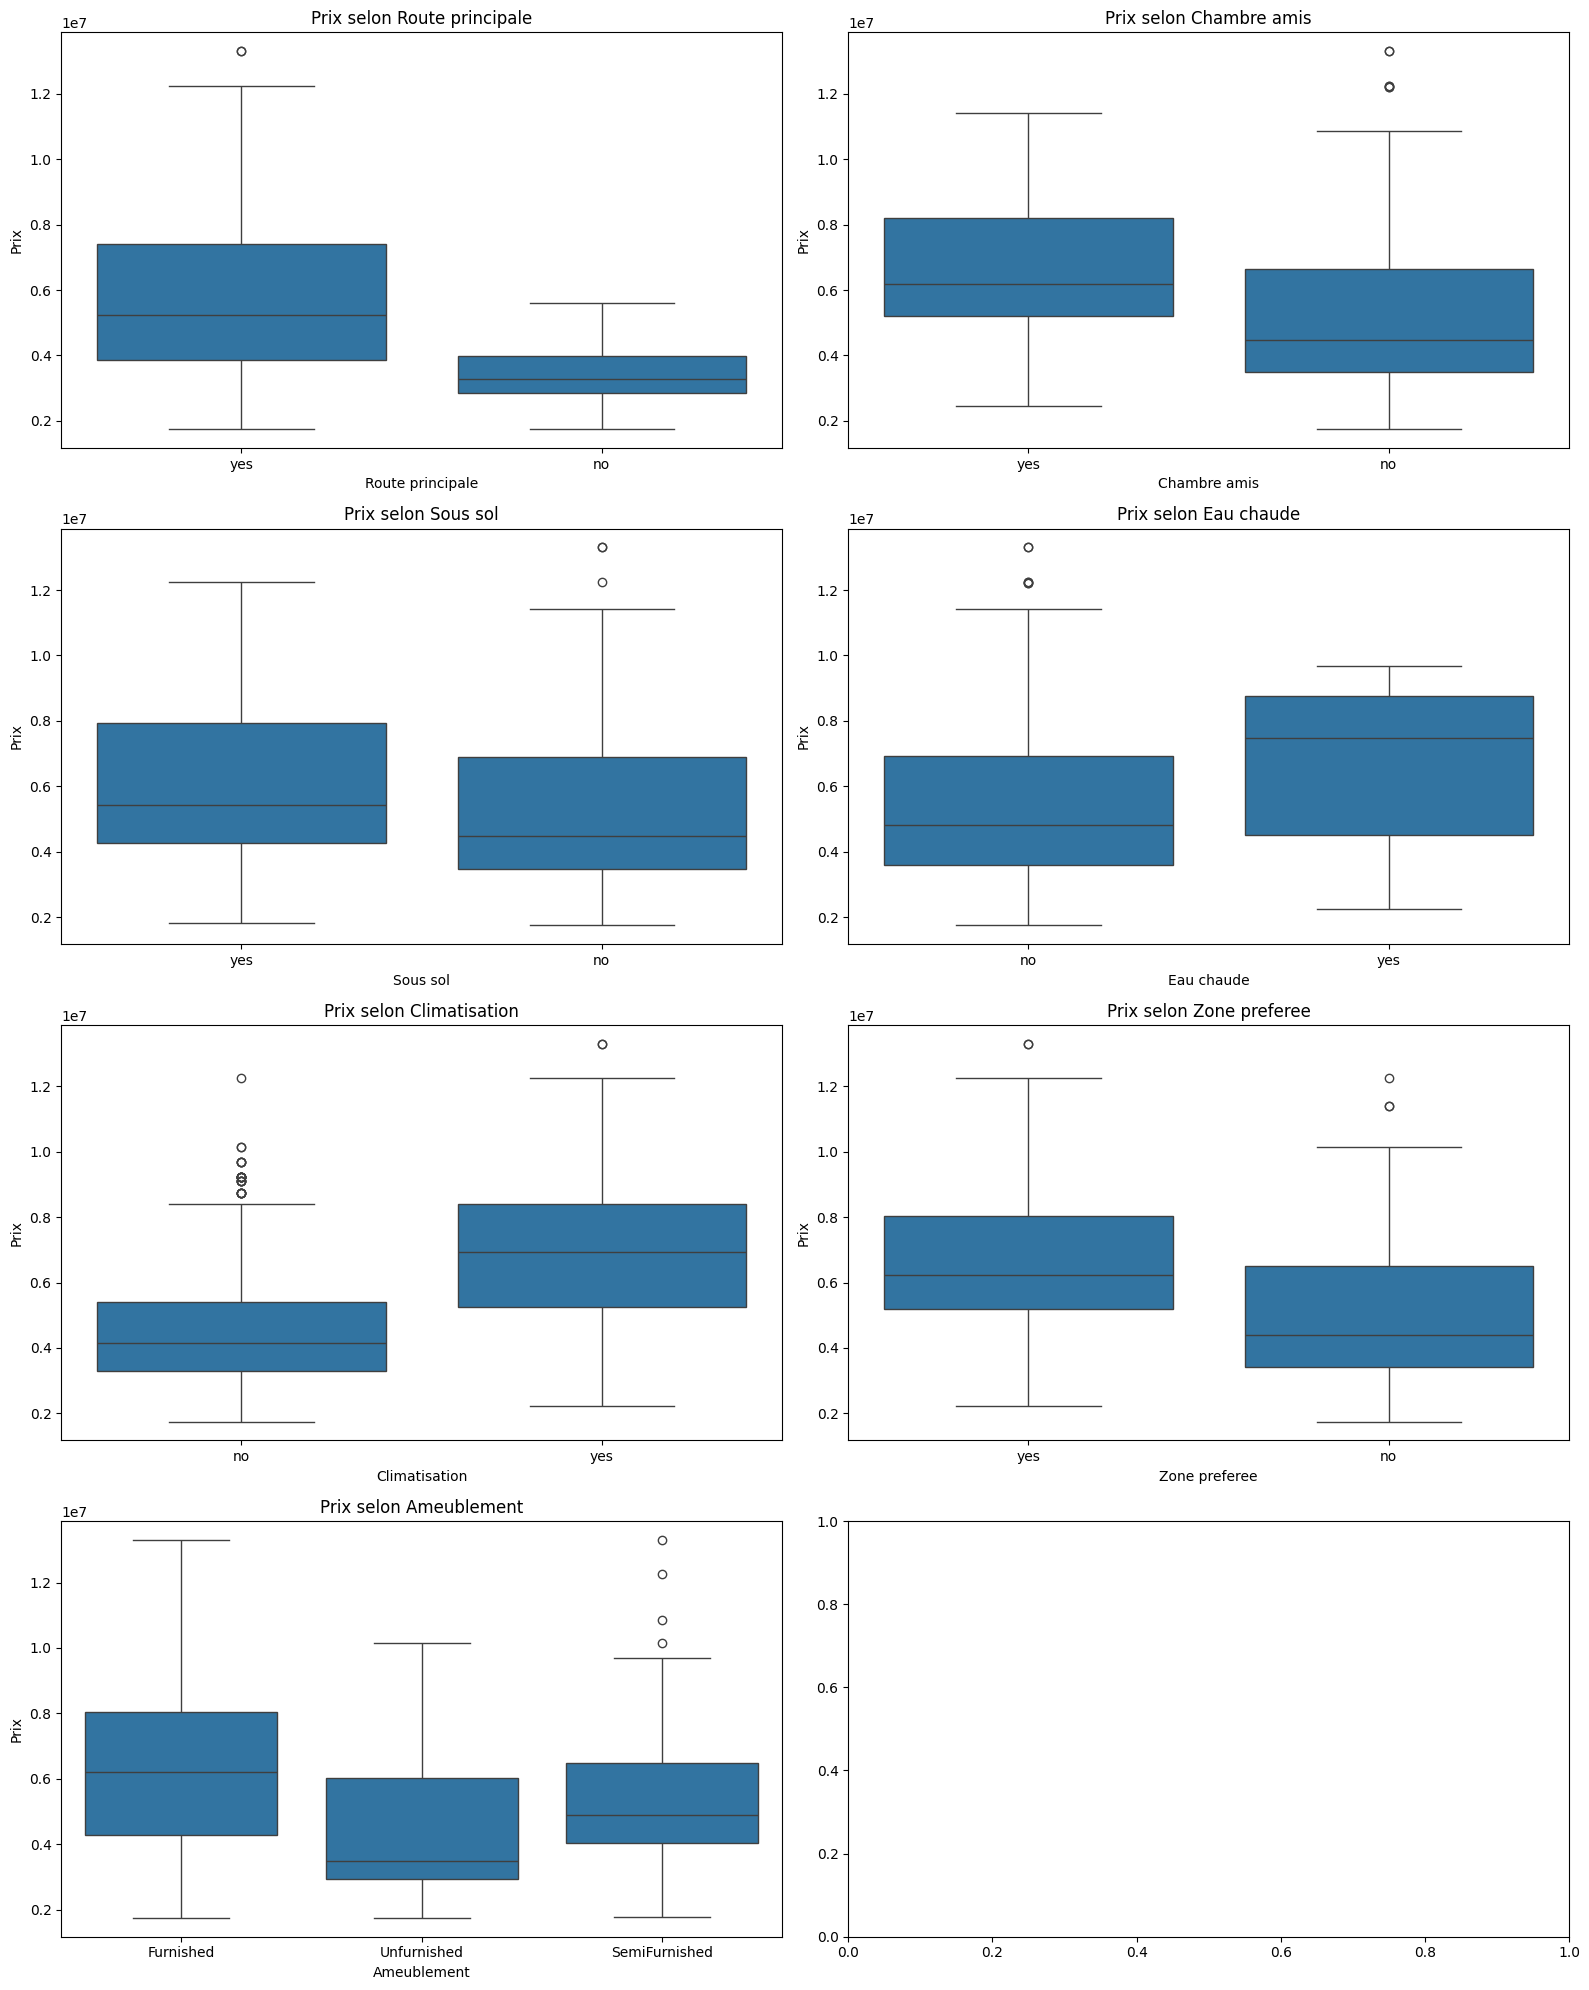

In [ ]:
# Liste des variables catégorielles
variables_categorielles = ["route_principale", "chambre_amis", "sous_sol", "eau_chaude", "climatisation", "zone_preferee", "ameublement"]

# Nombre de colonnes pour les subplots
n_cols = 2
n_rows = (len(variables_categorielles) + n_cols - 1) // n_cols

# Figure et axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

# Créer un boxplot pour chaque variable catégorielle
for i, var in enumerate(variables_categorielles):
    sns.boxplot(data=house, x=var, y='prix', ax=axes[i])
    axes[i].set_title(f"Prix selon {var.replace('_', ' ').capitalize()}", fontsize=12)
    axes[i].set_xlabel(var.replace('_', ' ').capitalize(), fontsize=10)
    axes[i].set_ylabel("Prix", fontsize=10)


# Ajuster les espaces
plt.tight_layout()
plt.show()


Les boxplots des prix des maisons en fonction de la climatisation, de l'eau chaude, de la route principale, du sous-sol, des chambres d'amis, et du statut de l'ameublement montre que le prix moyen des maisons disposant de ces caractéristiques est supérieur à celui des maisons qui en sont dépourvues. Un test ANOVA pourrait confirmer statistiquement la significativité de ces différences.

In [220]:
# Encodage des variables catégorielles
house_encoded = encoder_var(house.copy(), variables_categorielles)
print(house_encoded.head())

         prix  superficie  chambres  salles_de_bain  etages route_principale  \
0   4543000.0      4990.0       4.0             2.0     2.0                1   
1   8080940.0      7000.0       3.0             2.0     4.0                1   
2   8750000.0      4321.0       3.0             2.0     2.0                1   
3   1890000.0      1700.0       3.0             1.0     2.0                1   
4  12215000.0      7500.0       4.0             2.0     2.0                1   

  chambre_amis sous_sol eau_chaude climatisation  parking zone_preferee  \
0            1        1          0             0      0.0             1   
1            0        0          0             1      2.0             0   
2            0        1          1             0      2.0             0   
3            0        0          0             0      0.0             0   
4            0        1          0             1      3.0             1   

   ameublement  
0    Furnished  
1    Furnished  
2    Furnished  


### ACM pour les variables catégorielles 

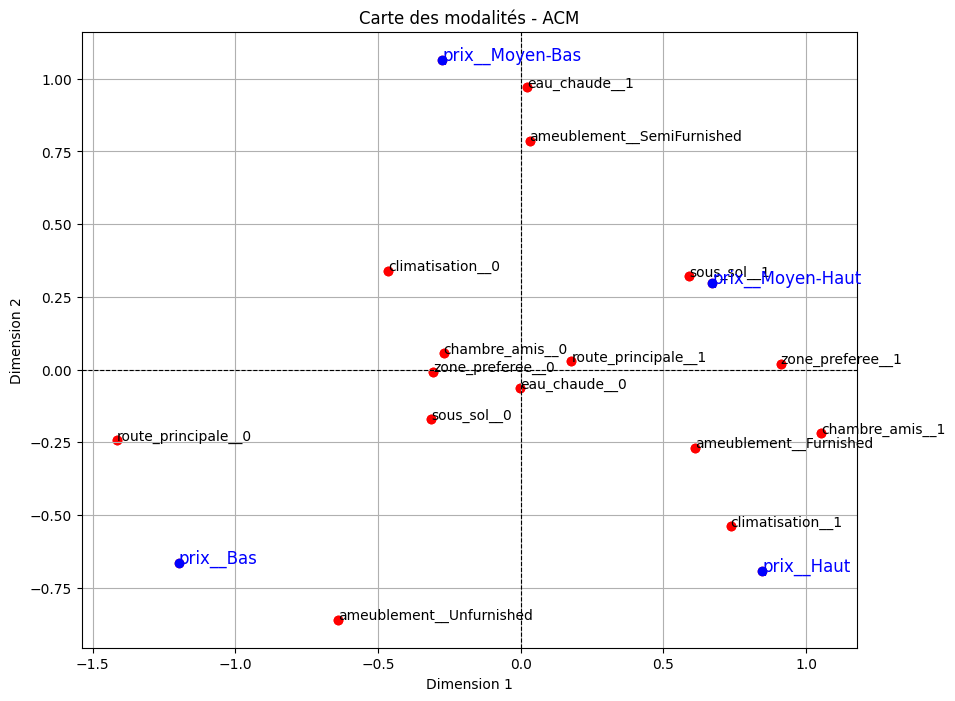

In [221]:
# Encodage de la variable 'prix' en 4 classes
house_encoded['prix'] = pd.qcut(house['prix'], q=4, labels=['Bas', 'Moyen-Bas', 'Moyen-Haut', 'Haut'])

variables_categorielles = ['route_principale', 'chambre_amis', 'sous_sol', 'eau_chaude', 'climatisation', 'zone_preferee', 'ameublement', 'prix']
mca = acm(house_encoded, variables_categorielles)
plot_acm_modalities(mca, house_encoded, variables_categorielles)

En analysant les résultats de l'Analyse des Correspondances Multiples (ACM), on observe que les maisons présentant des caractéristiques telles que la climatisation, l'eau chaude, un statut d'ameublement "Furnished" (meublé), situées dans une zone préférée et facilement accessibles par une route principale, ont tendance à être associées aux prix les plus élevés, voire très élevés.

En revanche, les maisons qui ne possèdent pas ces commodités ou qui ne répondent pas à ces critères (par exemple, absence de climatisation, statut d'ameublement "Unfurnished" ou "Semi-Furnished", absence d'eau chaude, situées dans des zones moins prisées et/ou sans accès direct à une route principale) sont majoritairement associées à des prix moyens à bas.

Cette analyse souligne l'importance de ces variables dans la détermination des prix des maisons, et leur influence peut être prise en compte dans les futurs modèles prédictifs pour une meilleure estimation du prix.



In [ ]:
# Test anova pour la variable catégorielle l'ameublement 

groupes = [house[house['ameublement'] == cat]['prix'] for cat in house['ameublement'].unique()]
anova_result = f_oneway(*groupes)
print(f"p-value: {anova_result.pvalue}")


p-value: 2.1022930274827917e-15


La p-value obtenue lors du test ANOVA indique une différence significative entre les prix des maisons en fonction de leur statut d'ameublement. Cela suggère qu'il est important de considérer le statut d'ameublement comme une variable pertinente dans la prédiction du prix des maisons.

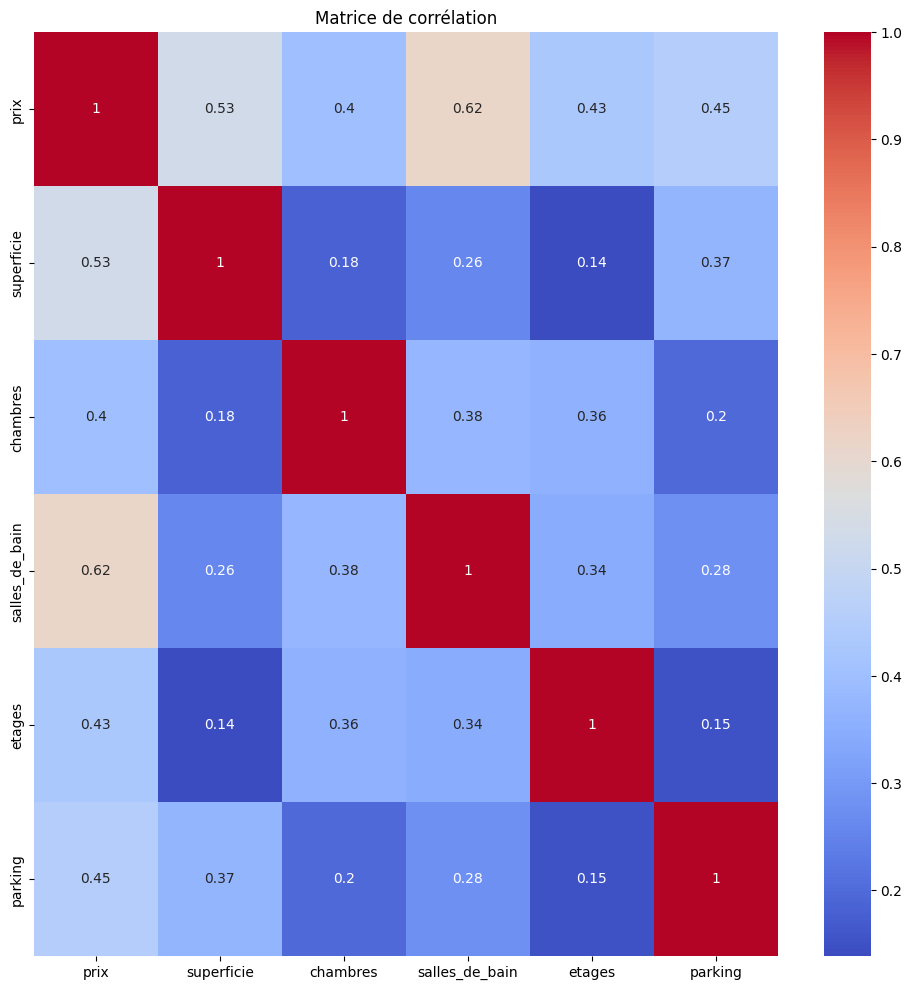

In [223]:
# matrice de corrélation 
plt.figure(figsize=(12,12))
sns.heatmap(house[variables_numeriques].corr(), annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()


**- Analyse de la matrice de corrélation**

La matrice de corrélation montre que la variable cible, prix de la maison, présente une corrélation significative avec les variables nombre de salles de bain et superficie de la maison. En revanche, les autres covariables affichent une corrélation plus faible avec le prix (inférieure à 0,5).

De plus, la corrélation entre les covariables elles-mêmes est globalement faible, ce qui indique qu'il n'y a pas de forte multicolinéarité entre les variables numériques. Cela suggère une relation linéaire marquée entre le prix des maisons et les variables superficie et salle de bain, tandis que les autres covariables ont un impact modéré sur le prix.

Ces observations fournissent des indications précieuses pour l'étape de modélisation, en soulignant que superficie et nombre de salles de bain sont probablement des prédicteurs clés pour estimer le prix des maisons.



# 1.4 Typage des variables

Le typage des variables est une étape cruciale dans la préparation des données pour les modèles de machine learning. Cette étape consiste à s'assurer que chaque variable est correctement définie, afin qu'elle soit traitée de manière appropriée par les algorithmes. Les variables numériques doivent être de type entier ou flottant, tandis que les variables catégorielles doivent être transformées en catégories ou encodées numériquement. Un typage correct est essentiel pour garantir des résultats fiables et optimaux lors de l'entraînement du modèle.

In [224]:
house.head()

,prix,superficie,chambres,salles_de_bain,etages,route_principale,chambre_amis,sous_sol,eau_chaude,climatisation,parking,zone_preferee,ameublement
0,4543000.0,4990.0,4.0,2.0,2.0,yes,yes,yes,no,no,0.0,yes,Furnished
1,8080940.0,7000.0,3.0,2.0,4.0,yes,no,no,no,yes,2.0,no,Furnished
2,8750000.0,4321.0,3.0,2.0,2.0,yes,no,yes,yes,no,2.0,no,Furnished
3,1890000.0,1700.0,3.0,1.0,2.0,yes,no,no,no,no,0.0,no,Unfurnished
4,12215000.0,7500.0,4.0,2.0,2.0,yes,no,yes,no,yes,3.0,yes,Furnished


In [225]:
house['route_principale'].unique()

array(['yes', 'no'], dtype=object)

In [226]:
# Appliquer cette fonction pour chaque variable binaire
for var in variables_categorielles:
    if house[var].nunique() == 2:  # Vérifier si la variable est binaire
        house[var] = transformer_binaire_en_entier(house, var)

# tester une variable pour voir
house['sous_sol'].head()


0    1
1    0
2    1
3    0
4    1
Name: sous_sol, dtype: int64

Nous allons maintenant procéder à l'encodage de la variable 'ameublement' en valeurs numériques. Pour ce faire, nous allons choisir comme modalité de référence 'Furnished', qui représente le statut d'ameublement complet de la maison.

In [227]:
# Transformation de la variable ameublement 
# modalité de référence 'Furnished'

house['Unfurnished']=(house['ameublement']=='Unfurnished').astype(int)
house['SemiFurnished']=(house['ameublement']=='SemiFurnished').astype(int)
house.drop('ameublement', axis=1, inplace=True)
house.head()




,prix,superficie,chambres,salles_de_bain,etages,route_principale,chambre_amis,sous_sol,eau_chaude,climatisation,parking,zone_preferee,Unfurnished,SemiFurnished
0,4543000.0,4990.0,4.0,2.0,2.0,1,1,1,0,0,0.0,1,0,0
1,8080940.0,7000.0,3.0,2.0,4.0,1,0,0,0,1,2.0,0,0,0
2,8750000.0,4321.0,3.0,2.0,2.0,1,0,1,1,0,2.0,0,0,0
3,1890000.0,1700.0,3.0,1.0,2.0,1,0,0,0,0,0.0,0,1,0
4,12215000.0,7500.0,4.0,2.0,2.0,1,0,1,0,1,3.0,1,0,0


# 2. Validation croisée

In [ ]:
# division des données en données d'entrainement et de test
X_train, X_test, y_train, y_test = split_data(house, 'prix', test_ratio=TEST_RATIO, seed=SEED)
X_train.shape, X_test.shape, y_train.shape, y_test.shape   # Vérification des dimensions

((566, 13), (243, 13), (566,), (243,))

Notre data frame 'house' est maintenant séparé en deux sous ensembles entrainement et test. 

# 3. Machine Learning

# 3.1 Modèle baseline 

Dans cette partie nous allons définir un modèle baseline qui determine le prix moyen d'une maison en fonction du nombre de chambre. 

Un modèle baseline peut être défini comme une fonction simple qui attribue à chaque maison le prix moyen basé sur son nombre de chambres. Nous commençons par calculer le prix moyen par nombre de chambres.

RMSE (Racine de l'erreur quadratique moyenne) du modèle baseline: 1960738.86


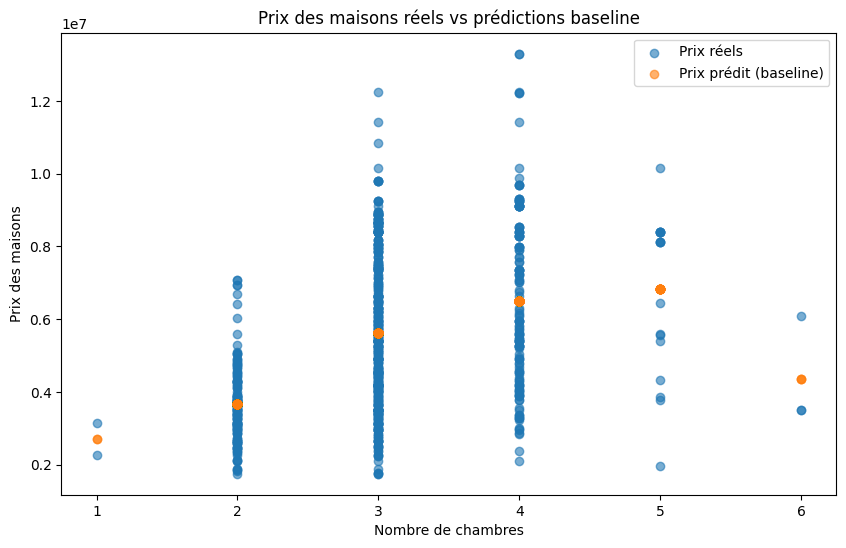

In [229]:
# Application du modèle baseline
prix_moyen_par_chambre = house.groupby("chambres")["prix"].mean()

# Fonction pour le modèle baseline
def modele_baseline(nombre_chambres):
    """
    Prédit le prix moyen basé sur le nombre de chambres.
    
    Args:
    nombre_chambres : int : Nombre de chambres.
    
    Returns:
    float : Prix moyen pour ce nombre de chambres.
    """
    return prix_moyen_par_chambre.get(nombre_chambres, prix_moyen_par_chambre.mean())

predictions_baseline = house["chambres"].apply(modele_baseline)

# Évaluation du modèle baseline
mae = mean_absolute_error(house["prix"], predictions_baseline)
rmse = np.sqrt(mean_squared_error(house["prix"], predictions_baseline))

# Affichage des résultats
print(f"RMSE (Racine de l'erreur quadratique moyenne) du modèle baseline: {rmse:.2f}")

# Visualisation des prédictions baseline

plt.figure(figsize=(10, 6))
plt.scatter(house["chambres"], house["prix"], label="Prix réels", alpha=0.6)
plt.scatter(house["chambres"], predictions_baseline, label="Prix prédit (baseline)", alpha=0.6)
plt.xlabel("Nombre de chambres")
plt.ylabel("Prix des maisons")
plt.title("Prix des maisons réels vs prédictions baseline")
plt.legend()
plt.show()

In [230]:
#pip install scikit-learn==1.5.2

**Interprétation du modèle baseline**
À travers les sorties obtenues, plusieurs observations peuvent être faites :

- Le prix moyen déterminé par le modèle baseline croît globalement avec le nombre de chambres, allant des maisons avec une chambre jusqu'à celles avec cinq chambres. Cela reflète une tendance intuitive : les maisons avec plus de chambres sont généralement plus chères.

- On observe que le prix moyen des maisons à 6 chambres est inférieur à celui des maisons avec 4 ou 5 chambres. Cela illustre qu’un plus grand nombre de chambres ne garantit pas un prix plus élevé. Ce comportement peut être dû à d'autres facteurs (localisation, taille globale de la maison, état de la propriété, etc.) qui ne sont pas pris en compte par ce modèle simple.
Écarts importants :

- Pour la plupart des maisons, on constate un écart important entre le prix réel et le prix moyen calculé par le modèle baseline.
Ce comportement est reflété par un RMSE (Racine de l'erreur quadratique moyenne) élevé : 1 960 738,86, indiquant une faible capacité du modèle baseline à capturer les variations des prix réels.

- Le nombre de chambres, pris isolément, est insuffisant pour prédire efficacement le prix d’une maison.
Ces résultats justifient la nécessité d'ajouter d’autres variables explicatives pour améliorer la prédiction des prix des maisons.

# 3.2 Modèle de régression linéaire 

# Explication du mèle linéaire

Nous allons construire un modèle regresssion qui prend en compte toutes les variables ou carateristique d'une maison. En allant de la regression linéaire simple à la regression linéaire généralisée en ajoutant progressivement les covariables.

Commençons par ajouetr la variable superficie à notre modèle baseline.


In [ ]:
# modèle regression linéaire utilisant chambres et superficie
model1 = ols('prix ~ superficie + chambres' , data=house).fit()
print(model1.summary())
# l'erreur quadratique moyenne
y_pred = model1.predict(house[['superficie', 'chambres']])
rmse = np.sqrt(mean_squared_error(house['prix'], y_pred))
print("La valeur de RMSE : ", rmse)

                            OLS Regression Results                            
Dep. Variable:                   prix   R-squared:                       0.374
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     241.0
Date:                Mon, 02 Dec 2024   Prob (F-statistic):           8.81e-83
Time:                        20:51:58   Log-Likelihood:                -12769.
No. Observations:                 809   AIC:                         2.554e+04
Df Residuals:                     806   BIC:                         2.556e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -3.818e+04   2.83e+05     -0.135      0.8

On peut voir que l'ajout de la nouvelle covariable superficie  diminue l'erreur moyenne quadratique en passant de 1960738.86 à 1731455.16  de notre modèle de base. La p-value indique la superficie a une effet significatif sur le prix d'une maison.

In [232]:
# modèle regression linéaire utilisant les variables superficies, chambres, salles_de_bain, etages, parking
model2 = ols('prix ~ superficie + chambres + salles_de_bain + etages + parking', data=house).fit()
print(model2.summary())
# l'erreur quadratique moyenne
y_pred = model2.predict(house[['superficie', 'chambres', 'salles_de_bain', 'etages', 'parking']])
rmse = np.sqrt(mean_squared_error(house['prix'], y_pred))
print(rmse)

                            OLS Regression Results                            
Dep. Variable:                   prix   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.603
Method:                 Least Squares   F-statistic:                     246.7
Date:                Mon, 02 Dec 2024   Prob (F-statistic):          1.58e-159
Time:                        20:51:58   Log-Likelihood:                -12582.
No. Observations:                 809   AIC:                         2.518e+04
Df Residuals:                     803   BIC:                         2.520e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept      -2.698e+05   2.28e+05     -1.

**1. Qualité du modèle**
- **R² (R-squared)** : **0.606**  
  - Environ **60,6 %** de la variance des prix est expliquée par les variables incluses dans le modèle (superficie, chambres, salles de bain, étages, parking).
  - Cela représente une amélioration significative par rapport au modèle univarié précédent (**R² = 0.232**).

- **Adj. R-squared** : **0.603**  
  - La version ajustée de R² reste proche de R², ce qui suggère que les variables ajoutées sont pertinentes.

- **F-statistic** : **246.7**, avec une probabilité associée (**Prob (F-statistic)**) extrêmement faible (**1.58e-159**) :
  - Cela confirme que le modèle global est significatif.


**Interprétation des coefficients** :
- Les **salles de bain** ont le plus grand effet sur le prix.
- Les **chambres** et la **superficie** ont également des impacts significatifs, mais moindres.
- Les **places de parking** et le **nombre d’étages** contribuent de manière modérée mais restent significatifs.


**4. Erreur quadratique moyenne (RMSE)**
- **RMSE** : **1,374,518.11**  
  - L'erreur moyenne entre les prix prédits et les prix réels reste importante, mais elle est nettement meilleure qu'avec le modèle défini par la superficie et le nombre de chambres (**1731455.16**).


**Remarques**
  
L'ajout de variables explicatives comme les salles de bain, la superficie, et les chambres améliore considérablement la capacité du modèle à prédire les prix des maisons, avec un R² passant de 0.280 à 0.606, ces variables étant cruciales dans la prédiction. Cependant, la présence potentielle de multicolinéarité et la non-normalité des résidus pourraient affecter la validité des résultats, nécessitant des ajustements tels que la régularisation ou des transformations des données. Pour aller plus loin, il serait pertinent de tester des modèles non linéaires comme Random Forest ou Gradient Boosting afin de mieux capturer les interactions complexes entre les variables et approfondir l’analyse des effets croisés pour une compréhension plus fine du problème.


In [233]:
# Modèle de régression linéaire multiple
model3 = ols('prix ~ superficie + chambres + salles_de_bain + etages + parking + route_principale + chambre_amis + sous_sol + eau_chaude + climatisation + zone_preferee + Unfurnished + SemiFurnished', data=house).fit()
print(model3.summary())
# l'erreur quadratique moyenne
y_pred = model3.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Erreur quadratique moyenne) du modèle: {rmse:.2f}")

                            OLS Regression Results                            
Dep. Variable:                   prix   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.704
Method:                 Least Squares   F-statistic:                     148.6
Date:                Mon, 02 Dec 2024   Prob (F-statistic):          1.97e-202
Time:                        20:51:58   Log-Likelihood:                -12460.
No. Observations:                 809   AIC:                         2.495e+04
Df Residuals:                     795   BIC:                         2.501e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -1.991e+05   2.48e+05  

Le modèle complet présente une très bonne capacité explicative avec un R² de 0.708, indiquant qu'il explique environ 70,8 % de la variance des prix des maisons, et un R² ajusté de 0.704, confirmant la pertinence des variables incluses. Sa performance est significativement améliorée par rapport au modèle de base, avec une réduction notable de la RMSE (1,205,776.49 contre 1,960,738.86). Les variables ayant le plus grand impact incluent la présence d'eau chaude, le nombre de salles de bain, la climatisation et la superficie, tandis que des facteurs comme le parking ou la route principale ont également une influence notable mais moindre.

# 3.3 Modèle ensembliste 

# Explication du modèle Ensembliste (Random Forest)

Le modèle Random Forest est un algorithme de machine learning ensembliste qui combine plusieurs arbres de décision pour améliorer la précision et la robustesse des prédictions. Utilisé principalement dans des contextes supervisés, il est adapté aussi bien à la classification qu’à la régression. Cet algorithme fonctionne en construisant de multiples arbres de décision sur des sous-échantillons aléatoires des données, puis en agrégeant leurs résultats, soit par vote majoritaire (classification), soit par moyenne (régression). Cette approche réduit le risque de surapprentissage (overfitting) et améliore la généralisation, tout en offrant une meilleure gestion de la variance et de la corrélation entre les prédicteurs.

Les principaux paramètres:

Nombre d’arbres (n_estimators):
Définit le nombre d’arbres dans la forêt. Un plus grand nombre d’arbres améliore généralement la stabilité et la précision du modèle, mais augmente aussi le temps de calcul.
Par exemple, avec 100 arbres, le modèle agrège les prédictions de 100 arbres indépendants pour produire une décision finale. Toutefois, après un certain seuil, l'augmentation du nombre d'arbres offre des gains marginaux en précision.

Profondeur maximale (max_depth) :
Limite la profondeur des arbres, c'est-à-dire le nombre de niveaux qu'un arbre peut atteindre. Une profondeur trop grande peut entraîner un surapprentissage, car les arbres deviennent trop spécifiques aux données d’entraînement.
Par défaut, les arbres sont développés jusqu’à ce que toutes les feuilles soient pures (contiennent des exemples homogènes) ou qu’elles atteignent la taille minimale des feuilles. Fixer une profondeur raisonnable permet de réduire la complexité et d'améliorer la capacité de généralisation.

Modèle de random forest 

In [ ]:
# Création du modèle
model_rf = RandomForestRegressor(n_estimators=100, random_state=SEED)
# Entraînement du modèle
model_rf.fit(X_train, y_train)
# Prédictions sur les données de test
y_pred_rf = model_rf.predict(X_test)
# Calcul de la RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(f"RMSE du modèle Random Forest: {rmse_rf:.2f}")

RMSE du modèle Random Forest: 1125479.64


L’utilisation du modèle Random Forest a considérablement réduit l’erreur par rapport au modèle de régression linéaire utilisant les mêmes covariables. Cette amélioration peut être attribuée à la capacité du Random Forest à capturer des relations non linéaires complexes et des interactions entre les variables explicatives, ce que la régression linéaire standard ne peut pas modéliser efficacement.

Cette diminution de l’erreur montre que le modèle Random Forest est plus adapté à ce problème de prédiction des prix des maisons, offrant des prédictions plus précises et robustes. Cependant, ce gain de performance a un coût en temps.

Variation du nombre d'arbdres

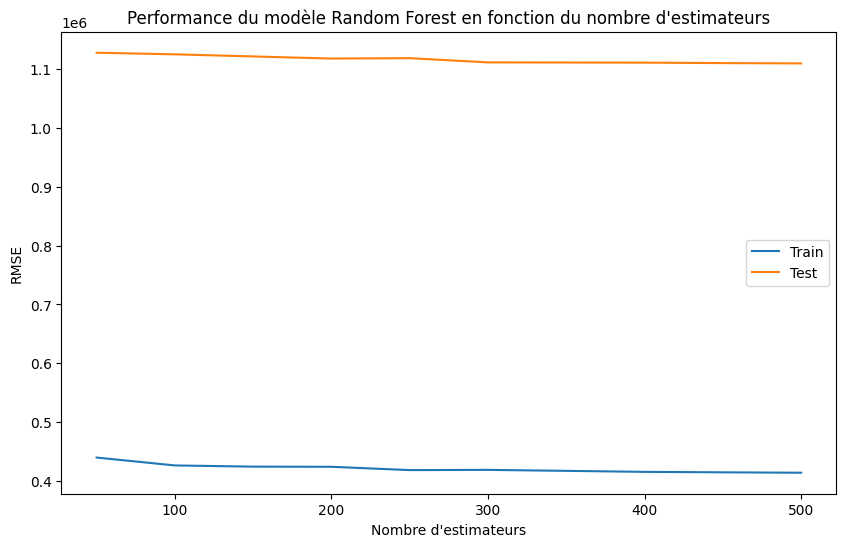

In [235]:
# faire varier le d'estimateurs pour voir l'impact sur le modèle 
# Liste des valeurs à tester
n_estimators = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
# Initialisation de la liste pour stocker les performances
performances_train = []
performances_test = []

# Boucle sur les valeurs de n_estimators
for n in n_estimators:
    # Création du modèle
    model_rf = RandomForestRegressor(n_estimators=n, random_state=SEED)
    # Entraînement du modèle
    model_rf.fit(X_train, y_train)
    # Prédictions sur les données d'entraînement
    y_pred_rf = model_rf.predict(X_train)
    # Calcul de la RMSE sur les données d'entraînement
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_rf))
    # Ajout de la performance à la liste
    performances_train.append(rmse_train)
    # Prédictions sur les données de test
    y_pred_rf = model_rf.predict(X_test)
    # Calcul de la RMSE sur les données de test
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    # Ajout de la performance à la liste
    performances_test.append(rmse_test)

# Affichage des performances
plt.figure(figsize=(10, 6))
plt.plot(n_estimators, performances_train, label="Train")
plt.plot(n_estimators, performances_test, label="Test")
plt.title("Performance du modèle Random Forest en fonction du nombre d'estimateurs")
plt.xlabel("Nombre d'estimateurs")
plt.ylabel("RMSE")
plt.legend()
plt.show()

Le graphique représente l'évolution de la RMSE en fonction du nombre d'estimateurs dans un modèle Random Forest, à la fois sur les ensembles d'entraînement et de test .

Ensemble d'entraînement :

La RMSE diminue rapidement au début, indiquant que l'ajout de plus d'arbres améliore la capacité du modèle à ajuster les données d'entraînement.
Après environ 200 estimateurs, la RMSE atteint une valeur presque constante. Cela montre que le modèle a atteint une capacité optimale pour expliquer les données d'entraînement et que l'ajout d'arbres supplémentaires n'améliore plus significativement les performances sur cet ensemble.

Ensemble de test :

La RMSE sur les données de test reste relativement stable après un certain point, autour de 200 estimateurs, ce qui reflète la bonne généralisation du modèle.
On observe une légère augmentation de la RMSE avec un grand nombre d'estimateurs.



ce qui pourrait être dû à des variations aléatoires dans les données ou à un ajustement excessif (bien que ce dernier soit limité pour un Random Forest).
Différence entre les ensembles d'entraînement et de test :

La RMSE sur l'ensemble d'entraînement est nettement plus faible que sur l'ensemble de test, ce qui est attendu car le modèle est optimisé pour les données d'entraînement.
Cependant, l'écart reste constant, ce qui indique que le modèle ne sur-apprend pas de manière excessive et conserve de bonnes performances de généralisation.

Conclusion :
Un nombre d'estimateurs compris entre 200 et 300 semble être un bon compromis entre performance et coût computationnel, car augmenter davantage le nombre d'arbres n'améliore que très peu les performances.

Le modèle montre de bonnes performances sur l'ensemble de test, avec un faible risque de surapprentissage. Toutefois, la légère augmentation de la RMSE pour un grand nombre d'arbres pourrait indiquer qu'il est préférable de limiter leur nombre pour éviter un ajustement inutilement complexe.

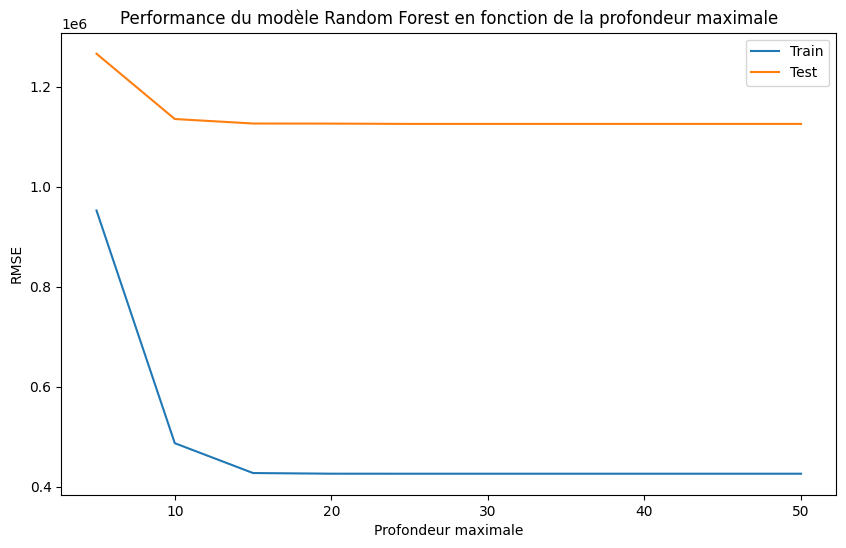

In [236]:
# Fais de même pour la profondeur maximale	
# Liste des valeurs à tester
max_depths = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
# Initialisation de la liste pour stocker les performances
performances_train = []
performances_test = []

# Boucle sur les valeurs de max_depth
for d in max_depths:
    # Création du modèle
    model_rf = RandomForestRegressor(n_estimators=100, max_depth=d, random_state=SEED)
    # Entraînement du modèle
    model_rf.fit(X_train, y_train)
    # Prédictions sur les données d'entraînement
    y_pred_rf = model_rf.predict(X_train)
    # Calcul de la RMSE sur les données d'entraînement
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_rf))
    # Ajout de la performance à la liste
    performances_train.append(rmse_train)
    # Prédictions sur les données de test
    y_pred_rf = model_rf.predict(X_test)
    # Calcul de la RMSE sur les données de test
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_rf))
    # Ajout de la performance à la liste
    performances_test.append(rmse_test)

# Affichage des performances
plt.figure(figsize=(10, 6))
plt.plot(max_depths, performances_train, label="Train")
plt.plot(max_depths, performances_test, label="Test")
plt.title("Performance du modèle Random Forest en fonction de la profondeur maximale")
plt.xlabel("Profondeur maximale")
plt.ylabel("RMSE")
plt.legend()

Le graphique montre l’évolution de la RMSE en fonction de la profondeur maximale des arbres dans un modèle Random Forest :

Train : La RMSE diminue rapidement avec l'augmentation de la profondeur, atteignant une stabilité autour de 20-30, indiquant que les arbres capturent efficacement les relations dans les données d'entraînement.

Test : La RMSE diminue initialement, puis se stabilise à partir d'une profondeur de 20, montrant que l'augmentation de la profondeur au-delà de ce seuil n'apporte pas de gains significatifs.

On en déduit que la profondeur maximale autour de 20 est idéale pour équilibrer complexité et performance sans risque de surapprentissage.

# 3.4. Features importances

             Feature  Importance
2     salles_de_bain    0.363400
0         superficie    0.336700
9            parking    0.045308
3             etages    0.042561
8      climatisation    0.033409
1           chambres    0.032966
11       Unfurnished    0.030826
7         eau_chaude    0.024355
6           sous_sol    0.023246
10     zone_preferee    0.022023
5       chambre_amis    0.021073
12     SemiFurnished    0.016780
4   route_principale    0.007353


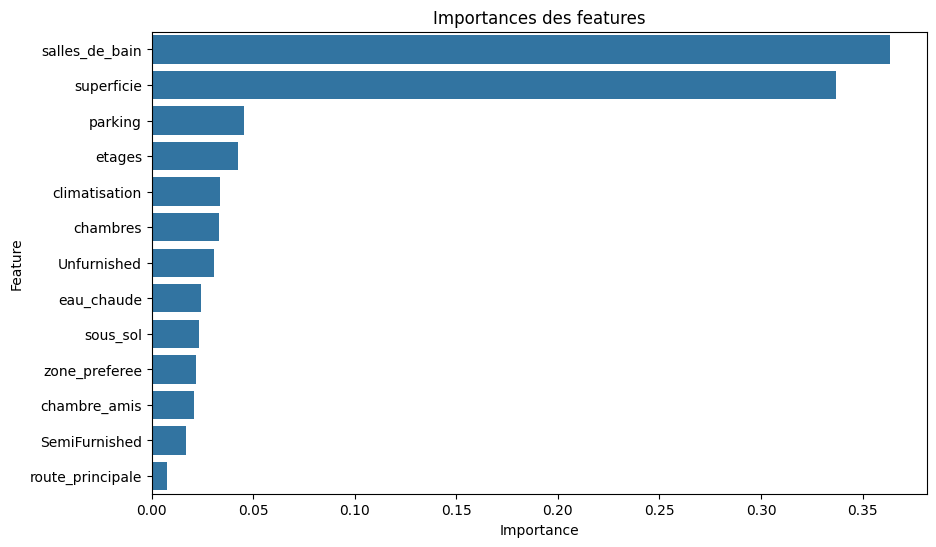

In [237]:
# Extraire les importances des features pour le modèle Random Forest
importances = model_rf.feature_importances_

# Créer un DataFrame pour les importances des features
features = X_train.columns
importances_df = pd.DataFrame({'Feature': features, 'Importance': importances})

# Trier les features par importance décroissante
importances_df = importances_df.sort_values(by='Importance', ascending=False)

# Afficher les importances des features
print(importances_df)

# Visualiser les importances des features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances_df)
plt.title('Importances des features')
plt.show()

La courbe des Features importances pour le modèle Random Forest met en évidence que les deux variables les plus importantes pour la prédiction des prix des maisons sont :

Salles de bain : Cette variable est la plus influente, avec une importance significative, reflétant que le nombre de salles de bain est un facteur clé dans la valorisation des maisons.

Superficie : La deuxième variable la plus importante, montrant que la taille de la maison (en m²) joue un rôle essentiel dans la détermination du prix.

Ces deux caractéristiques surpassent largement les autres en termes d'importance, indiquant qu'elles capturent une part substantielle de la variance dans les prix des maisons. Les autres variables, comme le parking, les étages, et la climatisation, ont une influence notable mais moindre, tandis que des facteurs comme la route principale ou le statut de l'ameublement ont une importance marginale. Cela suggère que les commodités et la taille physique de la maison sont les principaux moteurs de la variation des prix dans ce modèle.



# 4 Bonnus


## Tournage modèle ensembliste 


**RandomizedSearchCV** et **GridSearchCV** sont deux techniques de recherche d'hyperparamètres utilisées pour optimiser un modèle, mais elles diffèrent dans leur approche et leur performance :

1. GridSearchCV évalue toutes les combinaisons possibles des valeurs spécifiées pour chaque hyperparamètre, ce qui peut être très coûteux en temps de calcul. Il nécessite des listes fixes de valeurs pour chaque hyperparamètre.

2. RandomizedSearchCV, quant à lui, échantillonne un nombre fixe de combinaisons d'hyperparamètres à partir de distributions définies (par exemple, des distributions normales ou uniformes). Il ne teste pas toutes les combinaisons, mais en choisit un nombre défini par n_iter, ce qui le rend plus rapide, même pour des espaces de recherche très vastes.

3. Performance :
GridSearchCV est plus exhaustif, mais peut être très lent, surtout avec de nombreuses valeurs à tester.
RandomizedSearchCV est plus rapide car il évalue seulement un sous-ensemble des combinaisons possibles.

4. Flexibilité :
GridSearchCV ne permet que des listes fixes de valeurs.
RandomizedSearchCV peut utiliser des distributions continues, offrant plus de flexibilité pour explorer l'espace des hyperparamètres.

En résumé, GridSearchCV est plus complet mais coûte plus en temps de calcul, tandis que RandomizedSearchCV est plus rapide, mais moins exhaustif.


Application des deux techniques dans notre modèl de random forest

In [238]:
# Désactiver les avertissements généraux et FitFailedWarning
warnings.filterwarnings("ignore")
warnings.simplefilter('ignore', FitFailedWarning)

# Définir les paramètres à tester pour RandomizedSearchCV
param_distributions = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2'],  # Remplacer 'auto' par des valeurs valides
    'max_depth': [10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialiser le modèle
SEED = 42
rf = RandomForestRegressor(random_state=SEED)

# Utiliser RandomizedSearchCV pour trouver les meilleurs hyperparamètres
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=100,
    cv=3,
    verbose=0,  # Suppression des logs
    random_state=SEED,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés par RandomizedSearchCV
print("Meilleurs paramètres trouvés par RandomizedSearchCV:")
print(random_search.best_params_)

# Utiliser les meilleurs paramètres pour GridSearchCV
param_grid = {
    'n_estimators': [
        max(1, random_search.best_params_['n_estimators'] - 50),
        random_search.best_params_['n_estimators'],
        random_search.best_params_['n_estimators'] + 50
    ],
    'max_features': [random_search.best_params_['max_features']],
    'max_depth': [
        max(1, random_search.best_params_['max_depth'] - 10),
        random_search.best_params_['max_depth'],
        random_search.best_params_['max_depth'] + 10
    ],
    'min_samples_split': [random_search.best_params_['min_samples_split']],
    'min_samples_leaf': [random_search.best_params_['min_samples_leaf']],
    'bootstrap': [random_search.best_params_['bootstrap']]
}

# Utiliser GridSearchCV pour affiner les hyperparamètres
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=0  # Suppression des logs
)
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres trouvés par GridSearchCV
print("Meilleurs paramètres trouvés par GridSearchCV:")
print(grid_search.best_params_)

# Évaluer le modèle avec les meilleurs paramètres
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE du modèle affiné: {rmse:.2f}")


Meilleurs paramètres trouvés par RandomizedSearchCV:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10, 'bootstrap': False}
Meilleurs paramètres trouvés par GridSearchCV:
{'bootstrap': False, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 250}
RMSE du modèle affiné: 1074605.95



Analyse des résultats
Les deux méthodes convergent vers des hyperparamètres similaires, ce qui suggère que les valeurs optimales pour ce problème sont robustes.
Le choix de ne pas utiliser le bootstrap (par défaut dans Random Forest) indique que l’utilisation de l’ensemble complet des données pour chaque arbre améliore les performances dans ce cas spécifique.
Une profondeur maximale de 10 limite la complexité des arbres, évitant le surapprentissage tout en capturant suffisamment de relations dans les données.
L’utilisation de sqrt pour max_features réduit le nombre de variables considérées à chaque division, favorisant la diversité entre les arbres.
Performance du modèle
Le modèle affiné, avec un RMSE de 1,074,605.95, montre une amélioration par rapport au modèle précédent . Cela indique que l’optimisation des hyperparamètres a permis de mieux ajuster le modèle tout en maintenant un bon équilibre entre biais et variance.

En conclusion l'affinement du modèle grâce à RandomizedSearchCV et GridSearchCV a permis d'obtenir un modèle performant, bien régularisé grâce à une profondeur limitée, une sélection optimale des caractéristiques, et l'absence de bootstrap. Cependant, le RMSE reste élevé, suggérant que des gains supplémentaires pourraient être obtenus en explorant des techniques complémentaires comme l'intégration de nouvelles variables, le traitement des valeurs aberrantes, ou des modèles ensemblistes plus complexes comme le Gradient Boosting.

# Conclusion


L’objectif de ce projet était de développer un modèle de machine learning pour prédire les prix des maisons, en couvrant toutes les étapes, de la préparation des données à l’évaluation des performances du modèle. Nous avons commencé par une analyse exploratoire des données pour comprendre la distribution des variables et détecter d'éventuelles anomalies. Le traitement des données manquantes a été une étape cruciale pour garantir la fiabilité et éviter de biaiser les paramètres du modèle. Une analyse multivariée a permis d’identifier les relations entre la variable cible (le prix des maisons) et les variables explicatives, ainsi que les interactions entre ces dernières.

Dans le cadre de la modélisation, nous sommes partis d’un modèle baseline (régression linéaire simple) et avons progressivement évolué vers un modèle plus performant, en utilisant des approches ensemblistes telles que le Random Forest. Ce dernier a montré une meilleure capacité de prédiction avec une erreur (RMSE) plus faible par rapport au modèle de régression, mettant en évidence son aptitude à capturer des relations complexes entre les variables. L’analyse des importances des caractéristiques a révélé que les salles de bain et la superficie étaient les principaux facteurs influençant les prix.

Ce projet a permis d’acquérir une expertise dans la préparation des données, la création et l’interprétation de modèles de machine learning, ainsi que la communication des résultats. Ces connaissances peuvent être appliquées à des problématiques similaires dans le domaine immobilier ou dans d'autres secteurs. Les explorations additionnelle avec des techniques comme RandomizedSearchCV et GridSearchCV ont servi à affiner le modèle, bien que leur impact reste complémentaire.